In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder
)

# 1. LOAD DATASET
df = pd.read_csv("adult_with_headers (1).csv")

In [3]:
df.shape

(32561, 15)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# 2. BASIC DATA EXPLORATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [14]:
#here there is no null values in the data set

In [9]:
X = df.drop('income', axis=1)
y = df['income']

In [10]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (32561, 14)
Target: (32561,)


### Scaling Numerical Features

In [11]:
numeric_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

In [12]:
#standard scaling
standard_scaler = StandardScaler()

X_standard = X.copy()

X_standard[numeric_features] = standard_scaler.fit_transform(
    X_standard[numeric_features]
)

X_standard[numeric_features].head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [13]:
#min max scaling
minmax_scaler = MinMaxScaler()

X_minmax = X.copy()

X_minmax[numeric_features] = minmax_scaler.fit_transform(
    X_minmax[numeric_features]
)

X_minmax[numeric_features].head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


Standard Scaling is preferred when the features have different distributions and the algorithm benefits from zero-centered data. It is particularly useful for models such as Logistic Regression, SVM and KNN.

Min-Max Scaling is preferred when features need to be constrained to a specific range, commonly 0 to 1. However, it can be strongly affected by outliers because the minimum and maximum values determine the scaling range.

### Encoding Techniques:

In [15]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(col, ":", df[col].nunique())

workclass : 9
education : 16
marital_status : 7
occupation : 15
relationship : 6
race : 5
sex : 2
native_country : 42
income : 2


In [21]:
#One-Hot Encoding
df_encoded = df.copy()

df_encoded = pd.get_dummies(
    df_encoded,
    columns=['sex'],
    drop_first=True,
    dtype=int
)

df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Male
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,<=50K,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,<=50K,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,<=50K,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,<=50K,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,<=50K,0


In [22]:
#Label Encoding
label_columns = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'native_country'
]

In [23]:
from sklearn.preprocessing import LabelEncoder

df_label = df.copy()

label_encoders = {}

for col in label_columns:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col])
    label_encoders[col] = le

In [24]:
df_label.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,7,77516,9,13,4,1,1,4,Male,2174,0,40,39,<=50K
1,50,6,83311,9,13,2,4,0,4,Male,0,0,13,39,<=50K
2,38,4,215646,11,9,0,6,1,4,Male,0,0,40,39,<=50K
3,53,4,234721,1,7,2,6,0,2,Male,0,0,40,39,<=50K
4,28,4,338409,9,13,2,10,5,2,Female,0,0,40,5,<=50K


In [25]:
income_encoder = LabelEncoder()

df_label['income'] = income_encoder.fit_transform(df_label['income'])

In [26]:
print(df_label['income'].value_counts())

income
0    24720
1     7841
Name: count, dtype: int64


# One-Hot Encoding
### Advantages
    Does not impose an artificial order between categories.
    Suitable for nominal categorical variables.
    Works well with many machine learning algorithms.
### Disadvantages
    Increases the number of columns.
    Can create high-dimensional datasets when there are many categories.
    May increase memory usage.


# Label Encoding
### Advantages
    Simple and memory efficient.
    Does not increase the number of columns.
    Useful when dealing with many categories.
    Convenient for tree-based algorithms in many workflows.
### Disadvantages
    The numerical values can imply an ordering that may not actually exist.

### Feature Engineering

In [27]:
#Feature 1 – Capital Total
df['capital_total'] = df['capital_gain'] + df['capital_loss']

In [28]:
df[['capital_gain', 'capital_loss', 'capital_total']].head()

,capital_gain,capital_loss,capital_total
0,2174,0,2174
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [29]:
#Feature 2 – Work Intensity
df['work_intensity'] = df['hours_per_week'] / df['age']

In [30]:
df[['age', 'hours_per_week', 'work_intensity']].head()

,age,hours_per_week,work_intensity
0,39,40,1.025641
1,50,13,0.260000
2,38,40,1.052632
3,53,40,0.754717
4,28,40,1.428571


In [39]:
#Log Transformation
print("Skewness of capital_gain:", df['capital_gain'].skew())


Skewness of capital_gain: 11.953847687699799


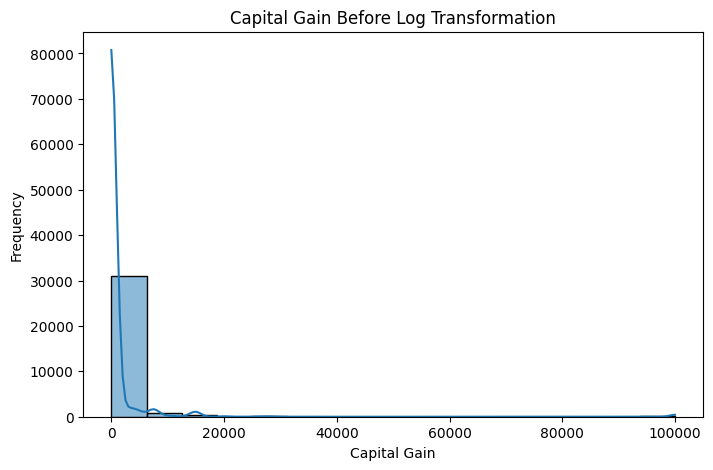

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df['capital_gain'], kde=True)

plt.title('Capital Gain Before Log Transformation')
plt.xlabel('Capital Gain')
plt.ylabel('Frequency')

plt.show()

In [41]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

In [42]:
print(df[['capital_gain', 'capital_gain_log']].head())

   capital_gain  capital_gain_log
0          2174          7.684784
1             0          0.000000
2             0          0.000000
3             0          0.000000
4             0          0.000000


In [43]:
print("Original skewness:",
      df['capital_gain'].skew())

print("Transformed skewness:",
      df['capital_gain_log'].skew())

Original skewness: 11.953847687699799
Transformed skewness: 3.096143524467517


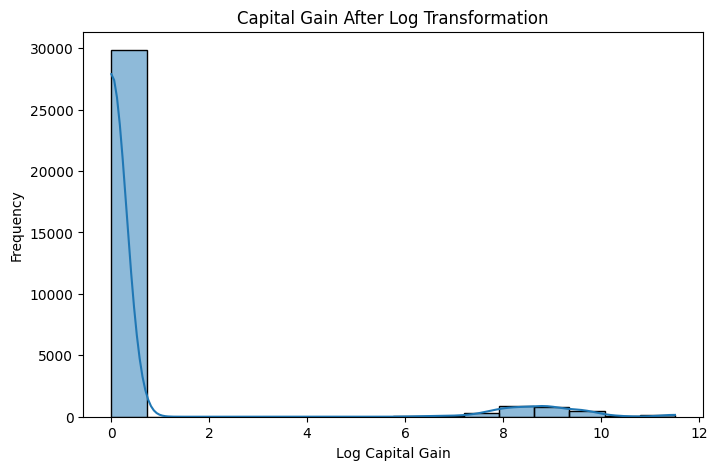

In [44]:
#after transformation
plt.figure(figsize=(8, 5))

sns.histplot(df['capital_gain_log'], kde=True)

plt.title('Capital Gain After Log Transformation')
plt.xlabel('Log Capital Gain')
plt.ylabel('Frequency')

plt.show()

#### Justification

The capital_gain feature is highly right-skewed because a large proportion of observations have zero capital gain, while a small number have extremely high values. The log1p() transformation was applied to reduce the effect of extreme values and make the distribution less skewed. log1p() was used because it can safely handle zero values.